# 📰 AG News Text Classification using BERT

## Project Overview
This project builds a deep learning model for automatic news classification using the **AG News** dataset and a pre-trained **BERT** transformer model from Hugging Face. The model is fine-tuned to classify news articles into one of four categories:

- 🌍 World
- ⚽ Sports
- 💼 Business
- 🔬 Sci/Tech


##Install important libraries


In [1]:
!pip install -U transformers
!pip install -U datasets huggingface_hub
!pip install gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 121.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datas

##Import important libraries

In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import gradio as gr
import huggingface_hub
from transformers import TrainingArguments, Trainer

##Load train and test sets

In [31]:
dataset = load_dataset('SetFit/ag_news')

small_train = dataset['train'].shuffle(seed=42).select(range(20000))
small_test = dataset['test'].shuffle(seed=42).select(range(5000))

##Tokenizer

In [32]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def pre_func(examples):
    return tokenizer(examples['text'], padding='max_length', max_length=256, truncation=True)

tokenized_train = small_train.map(pre_func, batched=True)
tokenized_test = small_test.map(pre_func, batched=True)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

##Build Model

In [33]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=4)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##Training

In [35]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True,          # GPU bo'lsa tezlashtiradi
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test
    )

trainer.train()

Step,Training Loss
100,0.190763
200,0.183448
300,0.184729
400,0.139510
500,0.147281
600,0.141098
700,0.120743
800,0.113309
900,0.124950
1000,0.145998


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2500, training_loss=0.12643864784240721, metrics={'train_runtime': 701.0722, 'train_samples_per_second': 57.055, 'train_steps_per_second': 3.566, 'total_flos': 5262315601920000.0, 'train_loss': 0.12643864784240721, 'epoch': 2.0})

##Evaluation

In [36]:
trainer.evaluate()

Training Loss,Validation Loss,Step
0.109616,0.306659,2500


{'eval_loss': 0.3066590428352356}

##Classification report and Confusion matrix


In [37]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = trainer.predict(tokenized_test)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

In [38]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

       World       0.94      0.94      0.94      1255
      Sports       0.99      0.98      0.99      1263
    Business       0.90      0.90      0.90      1248
    Sci/Tech       0.90      0.91      0.90      1234

    accuracy                           0.93      5000
   macro avg       0.93      0.93      0.93      5000
weighted avg       0.93      0.93      0.93      5000



In [39]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[1180    7   36   32]
 [  13 1242    5    3]
 [  32    4 1123   89]
 [  29    4   84 1117]]


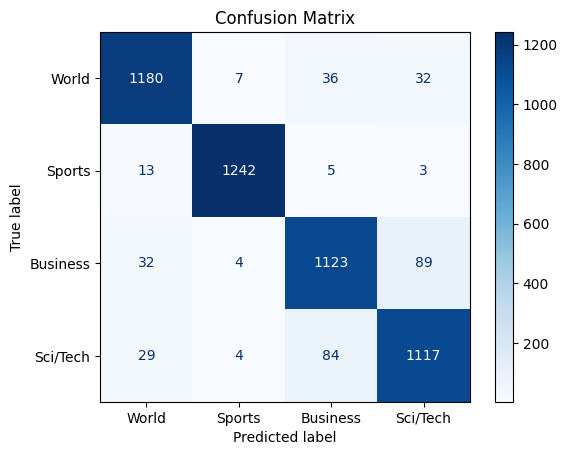

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

label_names = ["World", "Sports", "Business", "Sci/Tech"]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

##Model deployment (gradio)

In [41]:
def predict_news_category(text):
  inputs = tokenizer(text, padding=True, truncation = True, return_tensors='pt',max_length = 256).to('cuda')
  with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    label_names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

  return f'Category: {label_names[pred]}, Probability: {probs[0, pred].item():.2f}'

In [42]:
interface = gr.Interface(
    fn = predict_news_category,
    inputs = 'text',
    outputs = 'text',
    title = 'Find the category of news',
    description="Enter a news article or headline to predict its category"
    )

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://eef91040323abbd7b7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


##Save model

In [43]:
torch.save(model.state_dict(), 'news_model.pth')

In [11]:
#model.load_state_dict(torch.load('news_model.pth'))
#model.eval()